# A high-level analysis of the produce and price volatility in principal Canadian crops

## 1 Introduction

We have been hired as a data analyst by a US venture capital company, which has recently invested into the microbrewery and microdistillery industry. Our task is to perform a high-level analysis of crop production in Canada in order to inform our employer’s supply chain decisions. We therefore need to help the stakeholders understand the supply and price volatility of select crop types.

## 2 Executive summary

[SUMMARY HERE]

## 3 Report

### 3.1 Report introduction

We are given [Canadian principal crops data](https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMRP0203ENSkillsNetwork23863830-2021-01-01&pid=3210035901) (1908-2020) listing the measures of pricipal crop produce subsettable by province or territory, [farm product prices](https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMRP0203ENSkillsNetwork23863830-2021-01-01&pid=3210007701) (1980-2020) listing the average prices of farm produce and [Bank of Canada daily average exchange rates](https://www.bankofcanada.ca/rates/exchange/daily-exchange-rates?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMRP0203ENSkillsNetwork23863830-2021-01-01).

* areas in hectares
* production in metric tonnes

### 3.2 Deliverables

* create a database containing the relevant tables
* gather summary statistics the produce and prices of barley, canola and rye
* conduct a visual inspection of the crop and price series

### 3.3 Methods

The analysis below utilises the R programming language and the tidyverse library in processing and plotting the data. To obtain the data, we create a database and retrieve data with the SQLite dialect of SQL and the relevant libraries.

We use the following plots to visually assess volatility in the volume of produce and price series:

* time series
* ACF/PACF
* time series in first differences
* time series in logs
* rolling mean
* rolling standard deviation
* returns densities
* log returns densities
* squared returns ACF/PACF
* returns QQ plots
* boxplots
* candlesticks

### 3.4 Results

[RESULTS HERE]

### 3.5 Discussion

[DISCUSSION HERE]

#### 3.5.3 Limitations

* time series in nominal terms
* time series not seasonally adjusted
* low-frequency time series (months or years)
* very short fx time series not allowing to take movements in fx into account

### 3.6  Recommendations

* fit an ARCH/GARCH and/or more sophisticated statistical models 

In [346]:
# Libraries
library(tidyverse)
library(RSQLite)
library(DBI)

## Workings

### Helpers

In [347]:
# ggplot pallette
# Source: https://stackoverflow.com/a/8197703
gg_color_hue <- function(n) {
  hues = seq(15, 375, length = n + 1)
  hcl(h = hues, l = 65, c = 100)[1:n]
}


# SQL tab constructor
construct_tab <- function(channel, construction_query) {
    c <- channel
    q <- construction_query

    # Execute channel-query
    df <- tryCatch(
        dbExecute(c, q),
        error = function(e) e
    )

    # Check whether df is an error object
    if (inherits(df, "error")) {
        cat("An error has occurred.\n")
        print(df$message)
    } else {
        cat("Table has been created successfully.\n")
    }
}

In [ ]:
# Graphing helpers

# Set up Jupyter graph display
options(
  repr.plot.width  = 10,
  repr.plot.height = 6,
  repr.plot.res    = 150
)

# Set up a vector of colours
crop_colours <- setNames(
    gg_color_hue(3), 
    c("barley", "canola", "rye")
)

# Line and loess layers
line_layers <- list(
    geom_line(linewidth = 0.4),
    geom_smooth(
        method = "loess",
        formula = y ~ x,
        se = TRUE, # CI
        linewidth = 0.6,
        alpha = 0.4
    )
)

# Scale layers
vscale_layer <- function(vscale_vec, breaks = 10) {
    list(
        scale_y_continuous(
            limits = c(
                min(vscale_vec, na.rm = TRUE) - abs(min(vscale_vec, na.rm = TRUE) * 0.1), 
                max(vscale_vec, na.rm = TRUE) + abs(max(vscale_vec, na.rm = TRUE) * 0.1)
                ),
            breaks = scales::pretty_breaks(n = breaks)
        )
    )
}

hscale_layer <- function(breaks = "2 years") {
    list(
        scale_x_date(
            date_breaks = breaks,
            date_labels = "%Y"
        )
    )
}

# Events
events <- tibble(
    date  = as.Date(
        c(
            "1988-07-01",
            "1993-07-01",
            "2008-06-01",
            "2008-09-01",
            "2012-07-01",
            "2015-01-01",
            "2018-07-01",
            "2020-03-01"
        )
    ),
    label = c(
        "North American drought\n(1988)",
        "US Midwest floods\n(1993)",
        "Global food price\ncrisis (2008)",
        "Lehman Brothers\ncollapse (2008)",
        "US drought (2012)",
        "Oil price collapse\n(2014-2016)",
        "US-China trade war\n(2018)",
        "COVID-19 (2020)"
    )
)

# Event layers
event_layers <- list(
    geom_vline(
        data = events,
        aes(xintercept = date),
        linetype = "dashed",
        colour = "grey",
        linewidth = 0.4
    ),
    #geom_text()
    ggrepel::geom_text_repel(
        data = events,
        aes(x = date, y = Inf, label = label),
        angle = 0,
        #vjust = -0.5, # ggplot2
        #hjust = 1, # ggplot2
        size = 2.1,
        direction = "y", # ggrepel
        segment.size = 0.2, # ggrepel
        inherit.aes = FALSE,
        colour = "#CC5500"
    )
)

# Theme layers
common_theme <- function(guide = "none", angle = 45, txt_size = NULL) {
    if (guide == "colour") {
        list(
            theme_minimal(),
            theme(
                legend.position = "bottom",
                legend.direction = "horizontal"
            ),
            guides(colour = guide_legend(nrow = 1)),
            theme(axis.text.x = element_text(angle = angle, hjust = 1, size = txt_size))
        )
    } else if (guide == "fill") {
        list(
            theme_minimal(),
            theme(
                legend.position = "bottom",
                legend.direction = "horizontal"
            ),
            guides(fill = guide_legend(nrow = 1)),
            theme(axis.text.x = element_text(angle = angle, hjust = 1, size = txt_size))
        )
    } else {
        list(
            theme_minimal(),
            theme(
                legend.position = "bottom",
                legend.direction = "horizontal"
            ),
            theme(axis.text.x = element_text(angle = angle, hjust = 1, size = txt_size))
        )
    }
}

### Construct the database and load up the data

In [349]:
# Annual Crop Data
acd_path <- r"(https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-RP0203EN-SkillsNetwork/labs/Final%20Project/Annual_Crop_Data.csv)"

# Farm product prices
fpp_path <- r"(https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-RP0203EN-SkillsNetwork/labs/Final%20Project/Monthly_Farm_Prices.csv)"

# Daily FX Data
dfx_path <- r"(https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-RP0203EN-SkillsNetwork/labs/Final%20Project/Daily_FX.csv)"

# Monthly FX Data
mfx_path <- r"(https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-RP0203EN-SkillsNetwork/labs/Final%20Project/Monthly_FX.csv)"

In [350]:
# Establish an RSQLite connection
c <- dbConnect(SQLite(), "data/FinalDB_final_project.sqlite")

In [351]:
# Drop the tabs if they already exist
tab_vec <- c("crop_data", "prod_prices", "daily_fx", "monthly_fx")

for (tab in tab_vec) {
    q <- sprintf("
    DROP TABLE IF EXISTS %s;
    ", tab)
    dbExecute(c, q)
}

In [352]:
# Load the csvs into a list of data frames
path_vec <- c(acd_path, fpp_path, dfx_path, mfx_path)
name_vec <- c("acd_path", "fpp_path", "dfx_path", "mfx_path")
path_dic <- setNames(path_vec, name_vec)

data_list <- list()

for (path_name in names(path_dic)) {
    # Load up the dataset and clean the column names
    ds <- read_csv(
        path_dic[[path_name]],
        show_col_types = FALSE
    ) |> janitor::clean_names()
    
    # Add the df into the list
    data_list[[path_name]] <- ds

    # Obtain the column names for tab construction
    cat(path_name, "columns:\n", colnames(data_list[[path_name]]), "\n\n")
    # Obtain the data types
    #cat("Structure":\n", str(data_list[[path_name]]), "\n\n")
}

acd_path columns:
 cd_id year crop_type geo seeded_area harvested_area production avg_yield 

fpp_path columns:
 cd_id date crop_type geo price_prermt 

dfx_path columns:
 dfx_id date fxusdcad 

mfx_path columns:
 dfx_id date fxusdcad 



In [353]:
# Construct the tabs
construction_queries <- c(
    "
    CREATE TABLE IF NOT EXISTS crop_data (
        cd_id INTEGER NOT NULL,
        year DATE NOT NULL,
        crop_type VARCHAR(20) NOT NULL,
        geo VARCHAR(20) NOT NULL,
        seeded_area INTEGER NOT NULL,
        harvested_area INTEGER NOT NULL,
        production INTEGER NOT NULL,
        avg_yield INTEGER NOT NULL,
        PRIMARY KEY(cd_id)
    );
    ",
    "
    CREATE TABLE IF NOT EXISTS prod_prices (
        cd_id INTEGER NOT NULL,
        date DATE NOT NULL,
        crop_type VARCHAR(20) NOT NULL,
        geo VARCHAR(20) NOT NULL,
        price_prermt INTEGER NOT NULL,
        PRIMARY KEY (cd_id)
    );
    ",
    "
    CREATE TABLE IF NOT EXISTS daily_fx (
        dfx_id INTEGER NOT NULL,
        date DATE NOT NULL,
        fxusdcad FLOAT(6) NOT NULL,
        PRIMARY KEY(dfx_id)
    );
    ",
    "
    CREATE TABLE IF NOT EXISTS monthly_fx (
        dfx_id INTEGER NOT NULL,
        date DATE NOT NULL,
        fxusdcad FLOAT(6) NOT NULL,
        PRIMARY KEY(dfx_id)
    );
    "
)
construction_dic <- setNames(construction_queries, tab_vec)

for (tab in names(construction_dic)) {
    q <- construction_dic[[tab]]
    construct_tab(c, q)
}

Table has been created successfully.
Table has been created successfully.
Table has been created successfully.
Table has been created successfully.


In [354]:
# List tabs
dbListTables(c)

[1] "crop_data"   "daily_fx"    "monthly_fx"  "montly_fx"   "prod_prices"

In [355]:
# Load up SQLite database
for (i in seq_along(data_list)) {
    # Tab name
    tab_name <- tab_vec[i]
    # Write the tab into the database
    dbWriteTable(c, tab_name, data_list[[i]], overwrite = FALSE, append = TRUE, header = TRUE)
    # Retrieve the row count
    row_count <- dbGetQuery(c, sprintf("SELECT COUNT(*) FROM %s", tab_name)) |> pull()
    
    cat("Rows in", tab_name, ":", row_count, "\n")
}

Rows in crop_data : 672 
Rows in prod_prices : 2678 
Rows in daily_fx : 1033 
Rows in monthly_fx : 50 


In [356]:
# Clear the memory
rm(data_list)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,4375860,233.7,7951497,424.7,7951497,424.7
Vcells,12098867,92.4,25984036,198.3,25984036,198.3


### DB queries

In [357]:
# Format the dates
for (tab in tab_vec) {
    fields <- dbListFields(c, tab)

    if ("year" %in% fields) {
        date_col <- "year"
    } else {
        date_col <- "date"
    }

    # Rename the original date column
    q <- sprintf("
    ALTER TABLE %s RENAME COLUMN %s TO days_int;
    ", tab, date_col)
    dbExecute(c, q)

    # Add a column for date strings
    q <- sprintf("
    ALTER TABLE %s ADD COLUMN days_str TEXT;
    ", tab)
    dbExecute(c, q)

    # Add a column for the formatted date
    q <- sprintf("
    ALTER TABLE %s ADD COLUMN %s TEXT;
    ", tab, date_col)
    dbExecute(c, q)

    # Convert the number into a date-ready string
    # `||` SQL string concatenation operator; msql: CONCAT('hello', ' world')
    q <- sprintf("
    UPDATE %s
    SET days_str = CAST(days_int AS INTEGER) || ' days';
    ", tab)
    dbExecute(c, q)

    # Construct the date
    q <- sprintf("
    UPDATE %s
    SET %s = DATE('1970-01-01', days_str);
    ", tab, date_col)
    dbExecute(c, q)

    # Drop the helper cols
    q <- sprintf("
    ALTER TABLE %s
    DROP days_int;
    ", tab)
    dbExecute(c, q)

    q <- sprintf("
    ALTER TABLE %s
    DROP days_str;
    ", tab)
    dbExecute(c, q)
}

In [358]:
# Convert the crop prices
q <- "
SELECT
    p.*, 
    m.fxusdcad,
    (p.price_prermt / m.fxusdcad) AS price_usd
FROM prod_prices AS p, monthly_fx AS m
WHERE p.date = m.date
LIMIT 3;
"
dbGetQuery(c,q)

cd_id,crop_type,geo,price_prermt,date,fxusdcad,price_usd
<int>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
2324,Barley,Alberta,202.05,2017-01-01,1.319276,153.1522
2325,Barley,Saskatchewan,204.76,2017-01-01,1.319276,155.2063
2326,Canola,Alberta,482.78,2017-01-01,1.319276,365.9431


In [359]:
# Construct a temp fx col
q <- "
ALTER TABLE prod_prices
ADD fxusdcad FLOAT(6);
"
dbExecute(c, q)

[1] 0

In [360]:
# Construct a price (USD) col
q <- "
ALTER TABLE prod_prices
ADD price_usd FLOAT(6);
"
dbExecute(c, q)

[1] 0

In [361]:
# Populate the fx col
q <- "
UPDATE prod_prices
SET fxusdcad = (
    SELECT m.fxusdcad
    FROM monthly_fx AS m
    WHERE m.date = prod_prices.date
);
"
dbExecute(c, q)

[1] 2678

In [362]:
# Populate the price (USD) col
q <- "
UPDATE prod_prices
SET price_usd = price_prermt / fxusdcad;
"
dbExecute(c, q)

[1] 2678

In [363]:
# Check
q <- "
SELECT * FROM prod_prices
WHERE STRFTIME('%Y', date) >= '2017'
LIMIT 3;
"
dbGetQuery(c, q)

cd_id,crop_type,geo,price_prermt,date,fxusdcad,price_usd
<int>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
2324,Barley,Alberta,202.05,2017-01-01,1.319276,153.1522
2325,Barley,Saskatchewan,204.76,2017-01-01,1.319276,155.2063
2326,Canola,Alberta,482.78,2017-01-01,1.319276,365.9431


In [364]:
# Rename the price (CAD) col
q <- "
ALTER TABLE prod_prices
RENAME COLUMN price_prermt TO price_cad;
"
dbExecute(c, q)

[1] 0

In [365]:
# Delete the fx col
q <- "
ALTER TABLE prod_prices
DROP COLUMN fxusdcad;
"
dbExecute(c, q)

[1] 0

##### Subnational geographies

* consider the number of produce sources below the country level

In [366]:
# Geographies in the crop and farm prices datasets
q <- "
SELECT DISTINCT(geo) FROM crop_data
WHERE geo NOT IN ('Canada');
"
dbGetQuery(c, q)

geo
<chr>
Alberta
Saskatchewan


In [367]:
# Which geographies are included in the farm prices dataset?
q <- "
SELECT DISTINCT(geo) FROM prod_prices;
"
dbGetQuery(c, q)

geo
<chr>
Alberta
Saskatchewan


Our datasets feature prices for two unique geographies alone. Our concern, however, is the national rather than the provincial market. Province-specific volume of production does not concern us unless province-specific events dominate the country-wide volume of produce.

We shall adhere to a visual inspection. However, it ought to be considered later that there may be strong provincial-national correlations, especially since we have a very limited number of provinces at a lower level.

##### Crop reliability across the country

* consider the harvested-planted ratio
* consider the percentage of abandoned crops

In [368]:
# Look at the history of crops harvested in the whole of Canada
q <- "
SELECT
    year,
    crop_type,
    seeded_area,
    harvested_area,
    (harvested_area * 1.0 / seeded_area) AS harvested_planted_ratio,
    (seeded_area - harvested_area) * 1.0 / seeded_area * 100 AS percentage_abandoned
FROM crop_data
WHERE 
    LOWER(crop_type) IN ('barley', 'canola', 'rye') AND 
    STRFTIME('%Y', year) >= '1960' AND
    geo = 'Canada';
"
crops_of_interest_ts1 <- dbGetQuery(c, q)
crops_of_interest_ts1 |> 
    filter(harvested_planted_ratio != 1) |>
    head()

,year,crop_type,seeded_area,harvested_area,harvested_planted_ratio,percentage_abandoned
,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>
1,1973-12-31,Barley,4936800,4835800,0.9795414,2.045860
2,1974-12-31,Barley,4851700,4769150,0.9829853,1.701465
3,1975-12-31,Barley,4586450,4462450,0.9729638,2.703616
4,1976-12-31,Barley,4475450,4352950,0.9726285,2.737155
5,1977-12-31,Barley,4873600,4752600,0.9751724,2.482764
6,1978-12-31,Barley,4392500,4266500,0.9713147,2.868526


Note that the seeded and the harvested area is given in hectares.

In [369]:
# Pivot the df for plotting
crops_of_interest_ts1_long <- crops_of_interest_ts1 |>
    pivot_longer(
        cols = -c(crop_type, year),
        names_to = "var",
        values_to = "val"
    ) |>
    mutate(
        colour = case_when(
            str_to_lower(crop_type) == "barley" ~ crop_colours[["barley"]],
            str_to_lower(crop_type) == "canola" ~ crop_colours[["canola"]],
            str_to_lower(crop_type) == "rye" ~ crop_colours[["rye"]],
            .default = NA_character_
        )
    )

In [370]:
# Plot the harvested-planted ratio
df <- crops_of_interest_ts1_long |> 
    filter(var == "harvested_planted_ratio") |>
    mutate(year = year(year))

area_plot_hp <- ggplot(
        data = df,
        mapping = aes(x = year, y = val, colour = crop_type, group = crop_type)
    ) + 
    line_layers + 
    scale_colour_manual(values = str_to_sentence(crop_colours)) + 
    vscale_layer(df$val) +  # Defined in helpers
    scale_x_continuous(breaks = seq(min(df$year), max(df$year), 2)) +
    #event_layers_date + # Defined in helpers
    labs(
        title = "Harvested-planted ratio",
        subtitle = paste0("(Canada, ", year(min(cdf_sd$year)), "-", year(max(cdf_sd$year)), ")"),
        x = "Year",
        y = "Ratio",
        colour = ""
    ) +
    common_theme("colour") # Defined in helpers

# Plot the percentage abandoned
df <- crops_of_interest_ts1_long |> 
    filter(var == "percentage_abandoned") |>
    mutate(year = year(year))

area_plot_pa <- ggplot(
        data = df,
        mapping = aes(x = year, y = val, colour = crop_type, group = crop_type)
    ) + 
    line_layers + 
    vscale_layer(df$val) + 
    scale_x_continuous(breaks = seq(min(df$year), max(df$year), 2)) + 
    #event_layers_date +
    labs(
        title = "Percentage of area abandoned",
        subtitle = paste0("(Canada, ", year(min(cdf_sd$year)), "-", year(max(cdf_sd$year)), ")"),
        x = "Year",
        y = "Percentage",
        colour = ""
    ) +
    common_theme("colour")

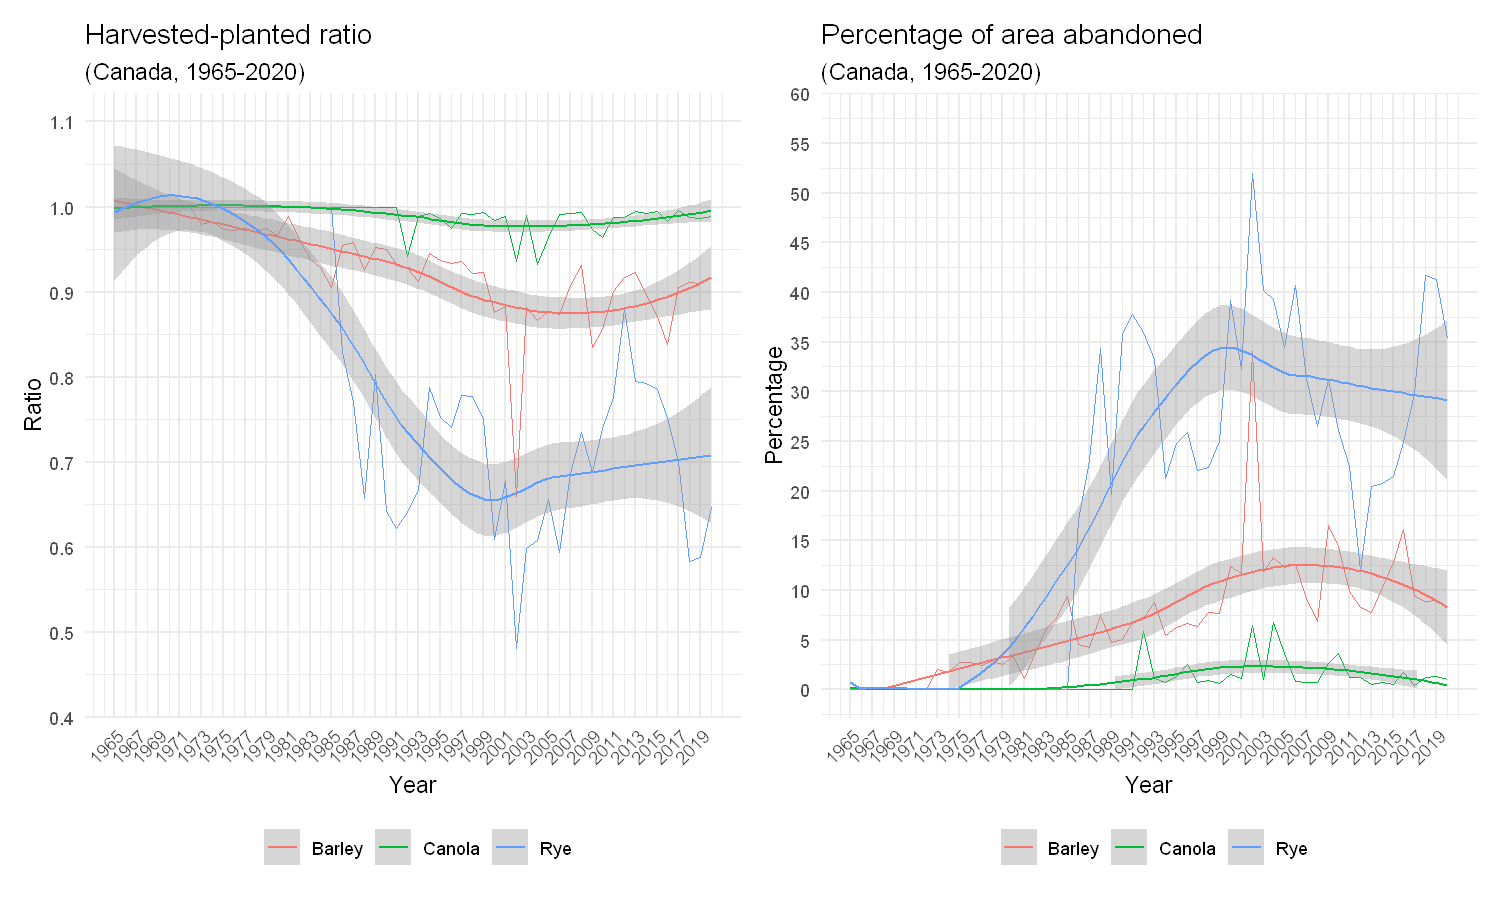

In [371]:
# Print the area plots
suppressWarnings({
    print(
        patchwork::wrap_plots(
            A = area_plot_hp, 
            B = area_plot_pa, 
            design = "AABB"
        )
    )
})

We can see that relatively little canola goes to waste, whereas substantial amounts of rye go unharvested. we may hazard a speculation that this is either due to a crop disease, rot, some inherent crop failure pattern or maybe a market glut and an excessively low price. We have not collected the weather data, but the datasets allow us to look at a naive relationship between the percentage abandoned and price. Assuming the laws of supply and demand hold, we may be able to rule out market glut as a cause.

We could perhaps also look at the specificity of harvest abandonment to either Alberta or Saskatchewan, but this seems less relevant to us as buyers from the Canadian market than the averages for the country.

There seems to be a noteworthy coincidence between the areas seeded and harvested in the barley data up to 1985 and in the canola data up to 1991.

##### Volatility of produce

* visualise the production time series with focus on volatility
* analyse the plots

In [372]:
# Look at the average volume of produce
q <- "
SELECT year, crop_type, production
FROM crop_data
WHERE
    LOWER(geo) = 'canada' AND
    LOWER(crop_type) IN ('barley', 'canola', 'rye');
"
crops_of_interest_ts2 <- dbGetQuery(c, q)

crops_of_interest_ts2 <- crops_of_interest_ts2 |>
    mutate(
        year = ymd(year),
        production = production / 1e6
    )

crops_of_interest_ts2 |> 
    #filter(production <= 0) |>
    #filter(is.infinite(log(production))) |>
    #summarise(na_count = sum(is.na(production))) |>
    #filter(is.na(production)) |>
    head()

,year,crop_type,production
,<date>,<chr>,<dbl>
1,1965-12-31,Barley,4.75290
2,1965-12-31,Canola,0.51260
3,1965-12-31,Rye,0.45340
4,1966-12-31,Barley,6.44995
5,1966-12-31,Canola,0.58510
6,1966-12-31,Rye,0.43760


In [373]:
# Plot the series

# Plot repo
crop_plots <- list()

# Vectors of name components
cseries <- c(
    # Monthly series unless stated
    "ts", # Time series
    #"acf", # ACF
    #"pacf", # PACF
    #"fd", # First differences
    "lt", # Time series in logs
    "rm", # Rolling mean
    "sd" # Rolling SD
    #"rd", # Returns distributions
    #"lr", # Log returns distributions
    #"ra", # Log returns ACF
    #"rp", # Log returns PACF
    #"qq", # QQ plots
    #"bp", # Boxplots (yearly)
)

# Time series
cdf_ts <- crops_of_interest_ts2

crop_plots[["cdf_ts"]] <- ggplot(
        data = cdf_ts,
        mapping = aes(x = year, y = production, colour = crop_type, group = crop_type)
    ) + 
    line_layers + # Defined in helpers 
    scale_colour_manual(values = str_to_sentence(crop_colours)) + # Defined in helpers
    vscale_layer(cdf_ts$production) + # Defined in helpers
    hscale_layer() + # Defined in helpers
    event_layers + # Defined in helpers
    labs(
        title = "Annual crop production",
        subtitle = paste0("(Canada, ", year(min(cdf_ts$year)), "-", year(max(cdf_ts$year)), ")"),
        x = "Year",
        y = "Production (millions of metric tonnes)",
        colour = ""
    ) +
    common_theme("colour") # Defined in helpers

    # Time series in logs
    cdf_lt <- crops_of_interest_ts2 |>
        mutate(production = log(production))

    crop_plots[["cdf_lt"]] <- ggplot(
        data = cdf_lt,
        mapping = aes(x = year, y = production, colour = crop_type, group = crop_type)
    ) + 
    line_layers +
    scale_colour_manual(values = str_to_sentence(crop_colours)) +
    vscale_layer(cdf_lt$production) + 
    hscale_layer() + 
    event_layers +
    labs(
        title = "Annual crop production (log scale)",
        subtitle = paste0("(Canada, ", year(min(cdf_lt$year)), "-", year(max(cdf_lt$year)), ")"),
        x = "Year",
        y = "Production (mm metric tonnes, logs)",
        colour = ""
    ) +
    common_theme("colour")

    # Time series in in first differences
    cdf_fd <- crops_of_interest_ts2 |>
        group_by(crop_type) |>
        mutate(production = production - lag(production)) |>
        ungroup() |>
        drop_na()

    crop_plots[["cdf_fd"]] <- ggplot(
        data = cdf_fd,
        mapping = aes(x = year, y = production, colour = crop_type, group = crop_type)
    ) + 
    line_layers +
    scale_colour_manual(values = str_to_sentence(crop_colours)) +
    vscale_layer(cdf_fd$production) + 
    hscale_layer() + 
    event_layers +
    labs(
        title = "Annual crop production (first differences)",
        subtitle = paste0("(Canada, ", year(min(cdf_fd$year)), "-", year(max(cdf_fd$year)), ")"),
        x = "Year",
        y = "Production (mm metric tonnes, differences)",
        colour = ""
    ) +
    common_theme("colour")

# Rolling mean
cdf_rm <- crops_of_interest_ts2 |>
    group_by(crop_type) |>
    mutate(roll_mean = zoo::rollapply(production, width = 12, FUN = mean, fill = NA)) |>
    ungroup()

crop_plots[["cdf_rm"]] <- ggplot(
        cdf_rm,
        aes(x = year, y = roll_mean, colour = crop_type, group = crop_type)
    ) +
    line_layers +
    vscale_layer(cdf_rm$roll_mean) + 
    hscale_layer() + 
    event_layers +
    labs(
        title = "Annual crop production (rolling mean)",
        subtitle = paste0("(Canada, ", year(min(cdf_rm$year)), "-", year(max(cdf_rm$year)), ")"),
        x = "Year",
        y = "Production (mm metric tonnes, roll mean)",
        colour = ""
    ) + 
    common_theme("colour")

# Rolling SD
cdf_sd <- crops_of_interest_ts2 |>
    group_by(crop_type) |>
    mutate(roll_sd = zoo::rollapply(production, width = 12, FUN = sd, fill = NA)) |>
    ungroup()

crop_plots[["cdf_sd"]] <- ggplot(
        cdf_sd,
        aes(x = year, y = roll_sd, colour = crop_type, group = crop_type)
    ) +
    line_layers +
    vscale_layer(cdf_sd$roll_sd) + 
    hscale_layer() + 
    event_layers +
    labs(
        title = "Annual crop production (rolling standard deviation)",
        subtitle = paste0("(Canada, ", year(min(cdf_sd$year)), "-", year(max(cdf_sd$year)), ")"),
        x = "Year",
        y = "Production (mm metric tonnes, roll SD)",
        colour = ""
    ) + 
    common_theme("colour")

NULL


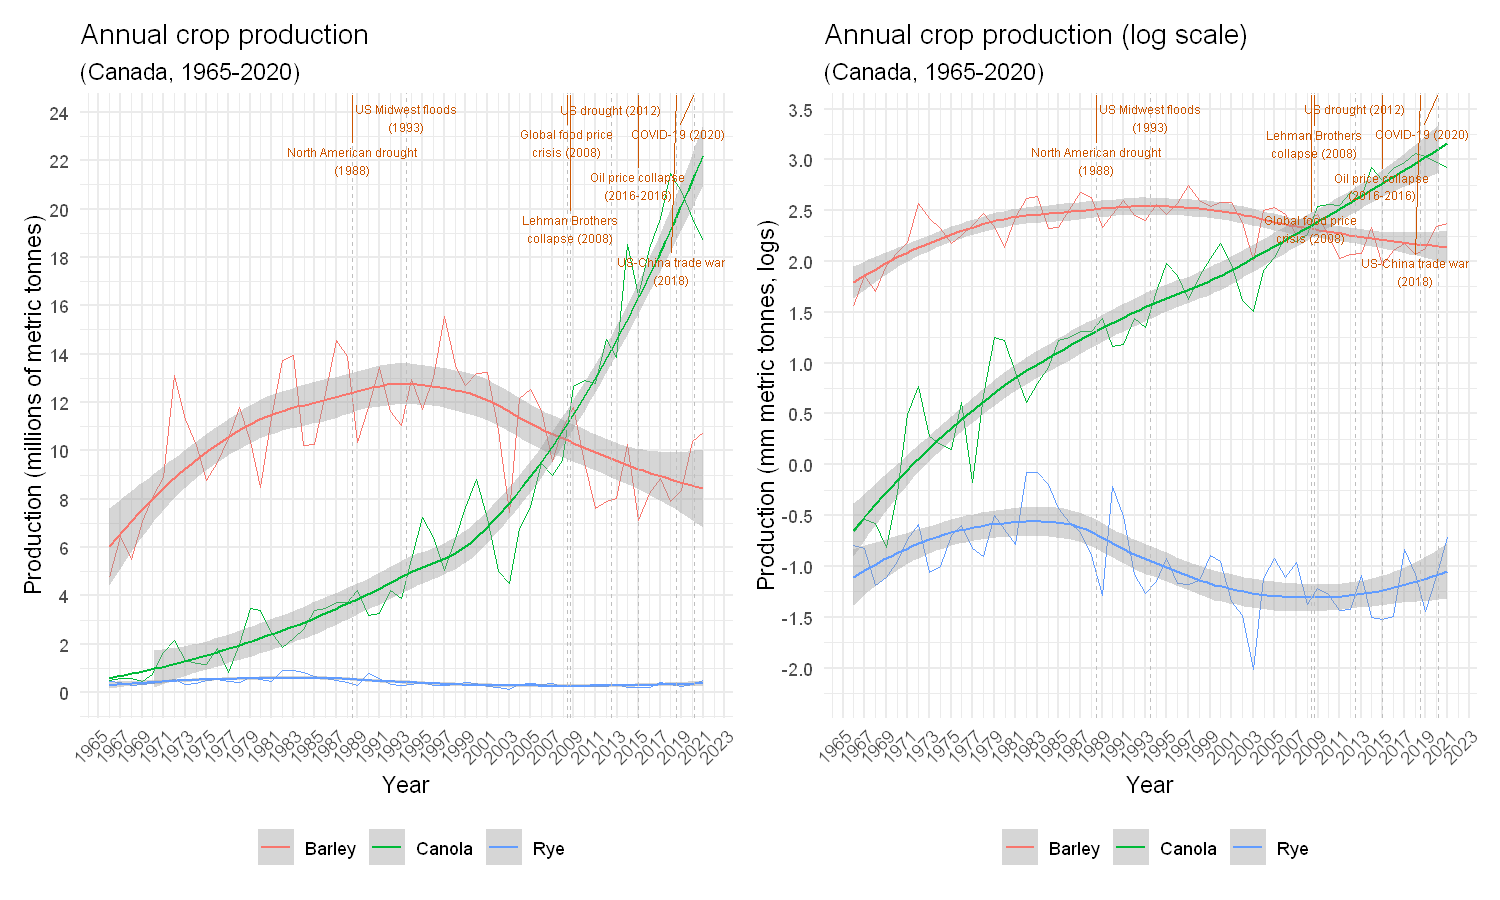

NULL


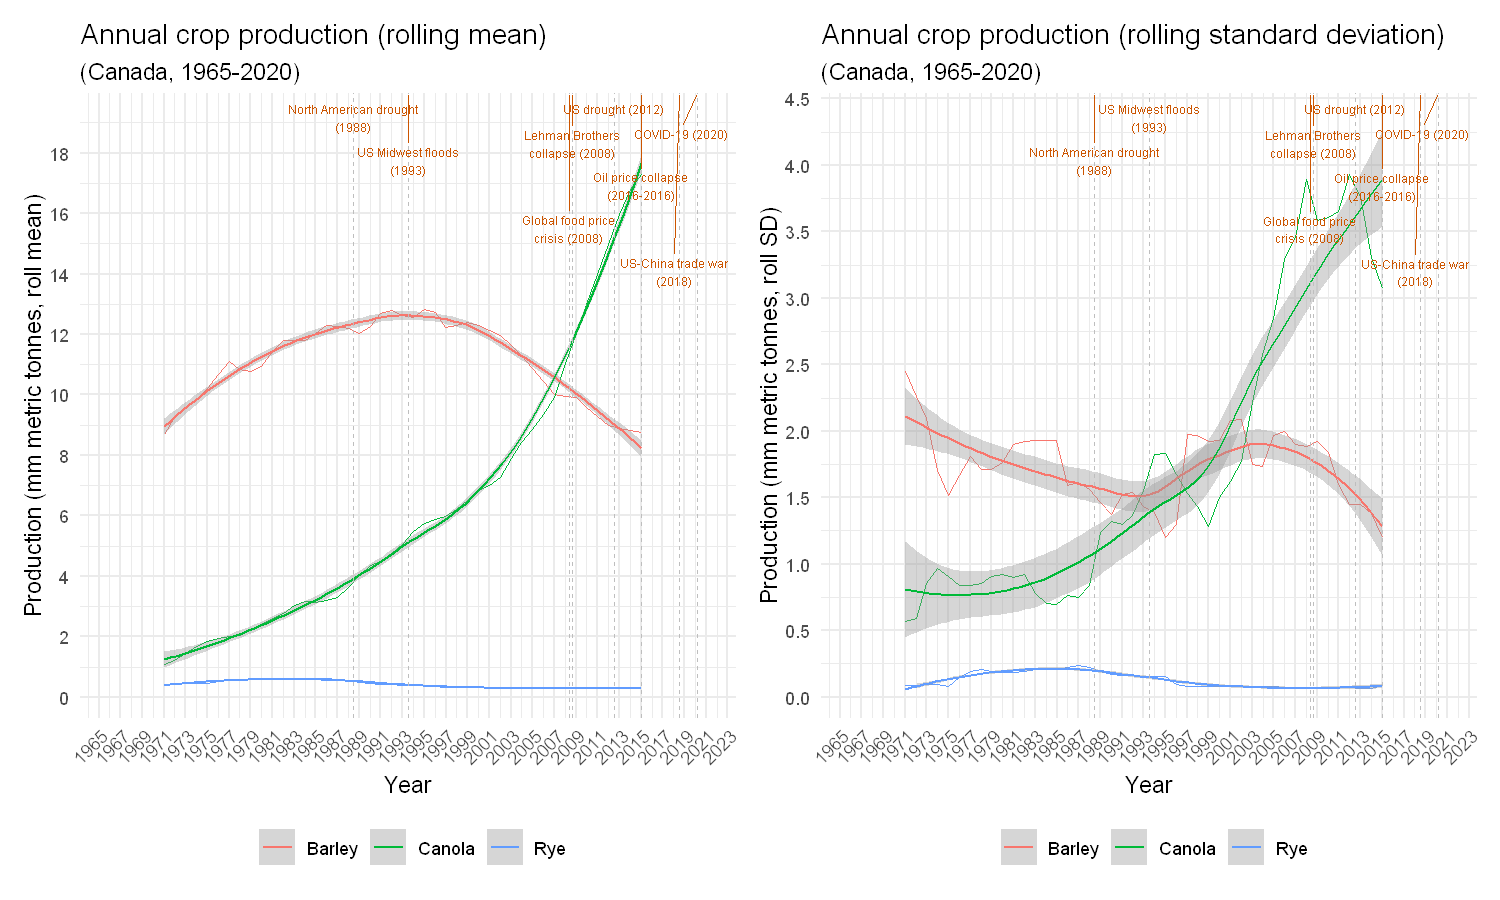

In [374]:
suppressWarnings({
    for (i in seq(1, length(cseries), 2)) { #s in cseries
        left_plot <- crop_plots[[paste0("cdf_", cseries[i])]]
        right_plot <- crop_plots[[paste0("cdf_", cseries[i + 1])]]
        print(
            patchwork::wrap_plots(
                A = left_plot, 
                B = right_plot, 
                design = "AABB"
            )
        )
        print(crop_plots[[paste0("cdf_", s)]])
    }
})

##### Volatility of prices

* visualise the price series in CAD and USD with focus on volatility
* analyse the plots

In [375]:
# Look at the average prices
q <- "
SELECT date, crop_type, AVG(price_cad) AS avg_price_cad, AVG(price_usd) AS avg_price_usd
FROM prod_prices
GROUP BY crop_type, date
HAVING LOWER(crop_type) IN ('barley', 'canola', 'rye');
"

prices_of_interest_ts1 <- dbGetQuery(c, q)
prices_of_interest_ts1 |>
    filter(date >= 2017) |>
    head()

,date,crop_type,avg_price_cad,avg_price_usd
,<chr>,<chr>,<dbl>,<dbl>
1,2017-01-01,Barley,203.405,154.1792
2,2017-02-01,Barley,212.860,162.3985
3,2017-03-01,Barley,199.305,148.8858
4,2017-04-01,Barley,166.735,124.0568
5,2017-05-01,Barley,158.760,116.6749
6,2017-06-01,Barley,160.005,120.3222


In [376]:
# Pivot the df for plotting
prices_of_interest_ts1_long <- prices_of_interest_ts1 |> 
    pivot_longer(
        cols = starts_with("avg_"),
        names_to = "var",
        values_to = "val"
    ) |>
    mutate(
        date = ymd(date),
        var_lab = paste0(crop_type, " (", str_to_upper(str_extract(var, "[a-z]{3}$")), ")")
    )

In [377]:
# Plot the price series

# Plot repo
price_plots <- list()

# Vector of candle stick colours
candle_colours <- gg_color_hue(3)

# Vectors of name components
currencies <- c("CAD", "USD")
series <- c(
    # Monthly series unless stated
    "ts", # Time series
    #"acf", # ACF
    #"pacf", # PACF
    "fd", # First differences
    "lt", # Time series in logs
    "rm", # Rolling mean
    "sd", # Rolling SD
    #"rd", # Returns distributions
    "lr", # Log returns distributions
    "ra", # Log returns ACF
    "rp", # Log returns PACF
    "qq", # QQ plots
    "bp", # Boxplots (yearly)
    "cs" # Candlesticks (yearly)
)

# Time series df
df_ts <- prices_of_interest_ts1_long

# ACF
df_acf <- prices_of_interest_ts1_long |>
    group_by(var_lab, crop_type) |>
    summarise(
        val_clean = list(zoo::na.approx(val, na.rm = FALSE)), # Linear interpolation
        acf_obj = list(acf(val_clean[[1]], plot = FALSE, na.action = na.pass)), # na.omit
        .groups = "drop"
    ) |> mutate(
        lag = map(acf_obj, ~ as.numeric(.$lag)),
        acf = map(acf_obj, ~ as.numeric(.$acf))
    ) |>
    select(-val_clean, -acf_obj) |>
    unnest(c(lag, acf))

# PACF
df_pacf <- prices_of_interest_ts1_long |>
    group_by(var_lab, crop_type) |>
    summarise(
        val_clean = list(zoo::na.approx(val, na.rm = FALSE)),
        pacf_obj = list(pacf(val_clean[[1]], plot = FALSE, na.action = na.pass)),
        .groups = "drop"
    ) |> mutate(
        lag = map(pacf_obj, ~ as.numeric(.$lag)),
        pacf = map(pacf_obj, ~ as.numeric(.$acf))
    ) |>
    select(-val_clean, -pacf_obj) |>
    unnest(c(lag, pacf))

# Time series in first differences df
df_fd <- prices_of_interest_ts1 |> 
    group_by(crop_type) |>
    mutate(
        across(
            .cols = starts_with("avg_"),
            .fns = ~ .x - lag(.x),
            .names = "fd_{.col}"
        )
    ) |>
    ungroup() |>
    select(-starts_with("avg_")) |>
    pivot_longer(
        cols = starts_with("fd_"),
        names_to = "var",
        values_to = "val"
    ) |>
    mutate(
        date = ymd(date),
        var_lab = paste0(crop_type, " (", str_to_upper(str_extract(var, "[a-z]{3}$")), ")")
    )

# Time series in logs df
df_lt <- prices_of_interest_ts1_long |>
    mutate(log_val = log(val))

# Rolling mean df
df_rm <- prices_of_interest_ts1_long |>
    group_by(var_lab, crop_type) |>
    mutate(roll_mean = zoo::rollapply(val, width = 12, FUN = mean, fill = NA))

# Rolling SD df
df_sd <- prices_of_interest_ts1_long |>
    group_by(var_lab, crop_type) |>
    mutate(roll_sd = zoo::rollapply(val, width = 12, FUN = sd, fill = NA))

# Returns df
df_rd <- prices_of_interest_ts1_long |>
    group_by(var_lab, crop_type) |>
    mutate(returns = (val - lag(val)) / lag(val))

# Log returns df
df_lr <- prices_of_interest_ts1_long |>
    group_by(var_lab, crop_type) |>
    mutate(log_returns = log(val) - log(lag(val)))

# Returns ACF
df_ra <- prices_of_interest_ts1_long |>
    group_by(var_lab, crop_type) |>
    mutate(
        # Returns ACF
        returns = list((val - lag(val)) / lag(val)),
        ret_clean = list(zoo::na.approx(returns[[1]], na.rm = FALSE)),
        racf_obj = list(acf(na.omit(ret_clean[[1]]), plot = FALSE)),
        # Log returns ACF
        log_returns = list(log(val / lag(val))),
        lret_clean = list(zoo::na.approx(log_returns[[1]], na.rm = FALSE)),
        lracf_obj = list(acf(na.omit(lret_clean[[1]]), plot = FALSE)),
        # Squared returns ACF
        sq_returns = list((returns[[1]])^2),
        sret_clean = list(zoo::na.approx(sq_returns[[1]], na.rm = FALSE)),
        sracf_obj = list(acf(na.omit(sret_clean[[1]]), plot = FALSE)),
        .groups = "drop"
    ) |>
    mutate(
        lag = map(racf_obj, ~ as.numeric(.$lag)),
        # Returns ACF
        ret_acf = map(racf_obj, ~ as.numeric(.$acf)),
        # Log returns ACF
        lret_acf = map(lracf_obj, ~ as.numeric(.$acf)),
        # Squared returns ACF
        sret_acf = map(sracf_obj, ~ as.numeric(.$acf)),
    ) |>
    select(-c(ends_with("clean"), ends_with("obj"))) |>
    unnest(c(lag, ret_acf, lret_acf, sret_acf))

# Returns PACF
df_rp <- prices_of_interest_ts1_long |>
    group_by(var_lab, crop_type) |>
    mutate(
        # Returns PACF
        returns = list((val - lag(val)) / lag(val)),
        ret_clean = list(zoo::na.approx(returns[[1]], na.rm = FALSE)),
        rpacf_obj = list(pacf(na.omit(ret_clean[[1]]), plot = FALSE)),
        # Log returns PACF
        log_returns = list(log(val / lag(val))),
        lret_clean = list(zoo::na.approx(log_returns[[1]], na.rm = FALSE)),
        lrpacf_obj = list(pacf(na.omit(lret_clean[[1]]), plot = FALSE)),
        # Squared returns PACF
        sq_returns = list((returns[[1]])^2),
        sret_clean = list(zoo::na.approx(sq_returns[[1]], na.rm = FALSE)),
        srpacf_obj = list(pacf(na.omit(sret_clean[[1]]), plot = FALSE)),
        .groups = "drop"
    ) |>
    ungroup() |> 
    mutate(
        lag = map(rpacf_obj, ~ as.numeric(.$lag)),
        # Returns PACF
        ret_pacf = map(rpacf_obj, ~ as.numeric(.$acf)),
        # Log returns PACF
        lret_pacf = map(lrpacf_obj, ~ as.numeric(.$acf)),
        # Squared returns PACF
        sret_pacf = map(srpacf_obj, ~ as.numeric(.$acf))
    ) |>
    select(-c(ends_with("clean"), ends_with("obj"))) |>
    unnest(c(lag, ret_pacf, lret_pacf, sret_pacf))

# Boxplot
year_levels <- sort(unique(year(prices_of_interest_ts1_long$date)))

df_bp <- prices_of_interest_ts1_long |>
    mutate(
        year = year(date),
        year_fac = factor(year, levels = year_levels)
    )

events_bp <- events |>
    mutate(
        year = year(date),
        year_fac = factor(year),
        year_pos = as.numeric(year_fac)
    )

# Candle stick df
df_cs <- prices_of_interest_ts1_long |>
    #filter(!is.na(val)) |>
    mutate(year = floor_date(date, "year")) |>
    arrange(var_lab, crop_type, year, date) |>
    group_by(var_lab, crop_type, year) |>
    summarise(
        open = first(val),
        close = last(val),
        high = max(val), #na.rm = TRUE
        low = min(val), #na.rm = TRUE
        .groups = "drop"
    )

suppressWarnings({
    for (currency in currencies) {
        # Time series
        df <- df_ts |>
            filter(str_detect(var_lab, currency))

        price_plots[[paste0(currency, "_ts")]] <- ggplot(
                data = df,
                mapping = aes(x = date, y = val, colour = crop_type, group = crop_type)
            ) + 
            line_layers +  # Defined in helpers
            scale_colour_manual(values = str_to_sentence(crop_colours)) + # Defined in helpers
            vscale_layer(df_ts$val) + # Defined in helpers
            hscale_layer() + # Defined in helpers
            event_layers + # Defined in helpers
            labs(
                title = "Crop prices",
                subtitle = paste0("(Canada, ", year(min(df$date)), "-", year(max(df$date)), ")"),
                x = "Year",
                y = paste0("Price (", currency, ")"),
                colour = ""
            ) +
            common_theme("colour")# Defined in helpers
        #print(price_plots[[paste0(currency, "_ts")]])

        # ACF
        df <- df_acf |>
            filter(str_detect(var_lab, currency))

        price_plots[[paste0(currency, "_acf")]] <- ggplot(
                df, 
                aes(x = lag, y = acf, fill = crop_type)
            ) +
            geom_bar(stat = "identity", position = "identity", colour = "black", linewidth = 0.1) +
            facet_wrap(~ crop_type) + 
            labs(
                title = paste0("ACF (", currency, " series)"),
                x = "Lag",
                y = "ACF",
                fill = ""
            ) +
            common_theme("fill")
        #print(price_plots[[paste0(currency, "_acf")]])

        # PACF
        df <- df_pacf |>
            filter(str_detect(var_lab, currency))

        price_plots[[paste0(currency, "_pacf")]] <- ggplot(
                df, 
                aes(x = lag, y = pacf, fill = crop_type)
            ) +
            geom_bar(stat = "identity", position = "identity", colour = "black", linewidth = 0.1) +
            facet_wrap(~ crop_type) + 
            labs(
                title = paste0("PACF (", currency, " series)"),
                x = "Lag",
                y = "PACF",
                fill = ""
            ) +
            common_theme("fill")
        #print(price_plots[[paste0(currency, "_pacf")]])

        # Time series in first differences
        df <- df_fd |>
            filter(str_detect(var_lab, currency))

        price_plots[[paste0(currency, "_fd")]] <- ggplot(
                data = df,
                mapping = aes(x = date, y = val, colour = crop_type, group = crop_type)
            ) + 
            geom_line(linewidth = 0.4) + 
            scale_colour_manual(values = str_to_sentence(crop_colours)) +
            vscale_layer(df_fd$val) +
            hscale_layer() + 
            event_layers +
            labs(
                title = "Crop prices (first differences)",
                subtitle = paste0("(Canada, ", year(min(df$date)), "-", year(max(df$date)), ")"),
                x = "Year",
                y = paste0("Price (", currency, ", differences)"),
                colour = ""
            ) +
            common_theme("colour")
        #print(price_plots[[paste0(currency, "_fd")]])

        # Time series in logs
        df <- df_lt |>
            filter(str_detect(var_lab, currency))

        price_plots[[paste0(currency, "_lt")]] <- ggplot(
                data = df,
                mapping = aes(x = date, y = log_val, colour = crop_type, group = crop_type)
            ) + 
            line_layers + 
            scale_colour_manual(values = str_to_sentence(crop_colours)) +
            vscale_layer(df_lt$log_val) + 
            hscale_layer() + 
            event_layers +
            labs(
                title = "Crop prices (log scale)",
                subtitle = paste0("(Canada, ", year(min(df$date)), "-", year(max(df$date)), ")"),
                x = "Year",
                y = paste0("Price (", currency, ", logs)"),
                colour = ""
            ) +
            common_theme("colour")
        #print(price_plots[[paste0(currency, "_lt")]])

        # Rolling mean
        df <- df_rm |>
            filter(str_detect(var_lab, currency))

        price_plots[[paste0(currency, "_rm")]] <- ggplot(
                df, 
                aes(x = date, y = roll_mean, colour = crop_type)
            ) +
            line_layers + 
            scale_colour_manual(values = str_to_sentence(crop_colours)) +
            vscale_layer(df_rm$roll_mean) + 
            hscale_layer() + 
            event_layers +
            labs(
                title = "Crop prices (rolling mean)",
                subtitle = paste0("(Canada, ", year(min(df$date)), "-", year(max(df$date)), ")"),
                x = "Year",
                y = paste0("Price (", currency, ", roll mean)"),
                colour = ""
            ) +
            common_theme("colour")
        #print(price_plots[[paste0(currency, "_rm")]])

        # Rolling standard deviation
        df <- df_sd |>
            filter(str_detect(var_lab, currency))

        price_plots[[paste0(currency, "_sd")]] <- ggplot(
                df, 
                aes(x = date, y = roll_sd, colour = crop_type)
            ) +
            line_layers + 
            scale_colour_manual(values = str_to_sentence(crop_colours)) +
            vscale_layer(df_sd$roll_sd) + 
            hscale_layer() + 
            event_layers +
            labs(
                title = "Crop prices (rolling standard deviation)",
                subtitle = paste0("(Canada, ", year(min(df$date)), "-", year(max(df$date)), ")"),
                x = "Year",
                y = paste0("Standard deviation (", currency, ", roll SD)"),
                colour = ""
            ) +
            common_theme("colour")
        #print(price_plots[[paste0(currency, "_sd")]])

        # Returns distributions
        df <- df_rd |>
            filter(str_detect(var_lab, currency))

        price_plots[[paste0(currency, "_rd")]] <- ggplot(
                df, 
                aes(x = returns, fill = crop_type)
            ) +
            geom_density(alpha = 0.5) +
            facet_wrap(~ crop_type) +
            labs(
                title = "Returns distributions",
                subtitle = paste0("(Canada, ", year(min(df$date)), "-", year(max(df$date)), ")"),
                x = "Returns",
                y = "Density",
                fill = ""
            ) +
            common_theme("colour")
        #print(price_plots[[paste0(currency, "_rd")]])

        # Log returns
        df <- df_lr |>
            filter(str_detect(var_lab, currency))

        price_plots[[paste0(currency, "_lr")]] <- ggplot(
                df, 
                aes(x = log_returns, fill = crop_type)
            ) +
            geom_density(alpha = 0.5) +
            facet_wrap(~ crop_type) +
            labs(
                title = "Log returns distributions",
                subtitle = paste0("(Canada, ", year(min(df$date)), "-", year(max(df$date)), ")"),
                x = "Returns (logs)",
                y = "Density",
                fill = ""
            ) +
            common_theme("fill")
        #print(price_plots[[paste0(currency, "_lr")]])

        # Squared returns ACF
        df <- df_ra |>
            filter(str_detect(var_lab, currency))

        price_plots[[paste0(currency, "_ra")]] <- ggplot(
                df, 
                aes(x = lag, y = sret_acf, fill = crop_type)
            ) +
            geom_bar(stat = "identity", position = "identity", colour = "black", linewidth = 0.1) +
            facet_wrap(~ crop_type) + 
            labs(
                title = paste0("ACF (", currency, ", squared returns)"),
                x = "Lag",
                y = "ACF",
                fill = ""
            ) +
            common_theme("fill")
        #print(price_plots[[paste0(currency, "_ra")]])

        # Squared returns PACF
        df <- df_rp |>
            filter(str_detect(var_lab, currency))

        price_plots[[paste0(currency, "_rp")]] <- ggplot(
                df, 
                aes(x = lag, y = sret_pacf, fill = crop_type)
            ) +
            geom_bar(stat = "identity", position = "identity", colour = "black", linewidth = 0.1) +
            facet_wrap(~ crop_type) + 
            labs(
                title = paste0("PACF (", currency, ", squared returns)"),
                x = "Lag",
                y = "PACF",
                fill = ""
            ) +
        common_theme("fill")
        #print(price_plots[[paste0(currency, "_rp")]])

        # Returns QQ plots
        df <- df_rd |>
            filter(str_detect(var_lab, currency))

        price_plots[[paste0(currency, "_qq")]] <- ggplot(
                df, 
                aes(sample = returns, colour = factor(crop_type))
            ) +
            stat_qq() +
            stat_qq_line() +
            labs(
                title = "Returns (qq plots)",
                subtitle = paste0("(Canada, ", year(min(df$date)), "-", year(max(df$date)), ")"),
                x = "Normal theoretical quantiles",
                y = "Normal data quantiles",
                colour = ""
            ) +
            common_theme("fill")
        #print(price_plots[[paste0(currency, "_qq")]])

        # Boxplots
        df <- df_bp |>
            # Keep NAs to retain the time-frame and x-scale for comparison
            filter(str_detect(var_lab, currency)) # |> drop_na()

        price_plots[[paste0(currency, "_bp")]] <- ggplot(
                df, 
                aes(x = factor(year), y = val, fill = crop_type)
            ) +
            geom_boxplot(linewidth = 0.1) +
            facet_wrap(~ crop_type, ncol = 1, scales = "free_y") +
            # Keep a common scale for parallel comparison
            vscale_layer(df_bp$val) +
            labs(
                title = "Crop prices (distributions)",
                subtitle = paste0("(Canada, ", year(min(df$date)), "-", year(max(df$date)), ")"),
                x = "Year",
                y = paste0("Price (", currency, ")"),
                fill = ""
            )  +
            common_theme("none", 90, 7)
        #print(price_plots[[paste0(currency, "_bp")]])

        # Candlestick plot
        df <- df_cs |>
            filter(str_detect(var_lab, currency))

        price_plots[[paste0(currency, "_cs")]] <- ggplot(
                df, 
                aes(x = year)
            ) +
            geom_linerange(
                aes(ymin = low, ymax = high)
            ) +
            geom_crossbar(
                aes(
                    y = (open + close) / 2,
                    ymin = pmin(open, close),
                    ymax = pmax(open, close),
                    fill = close > open
                ), 
                width = 100,
                linewidth = 0.1
            ) +
            # Keep a common scale for parallel comparison
            vscale_layer(df_cs$low) + 
            scale_x_date(
                date_breaks = "2 years",
                date_labels = "%Y"
            )  +
            scale_fill_manual(
                values = c("TRUE" = candle_colours[2], "FALSE" = candle_colours[1]), 
                guide = "none"
            ) +
            facet_wrap(~ crop_type, ncol = 1, scales = "free_y") +
            labs(
                title = "Crop prices (candlestick plot)",
                subtitle = paste0("(Canada, ", format(min(df$year), "%Y"), "-", format(max(df$year), "%Y"), ")"),
                x = "Year",
                y = paste0("Price (", currency, ")")
            ) +
            common_theme()
        #print(price_plots[[paste0(currency, "_cs")]])
    }
})

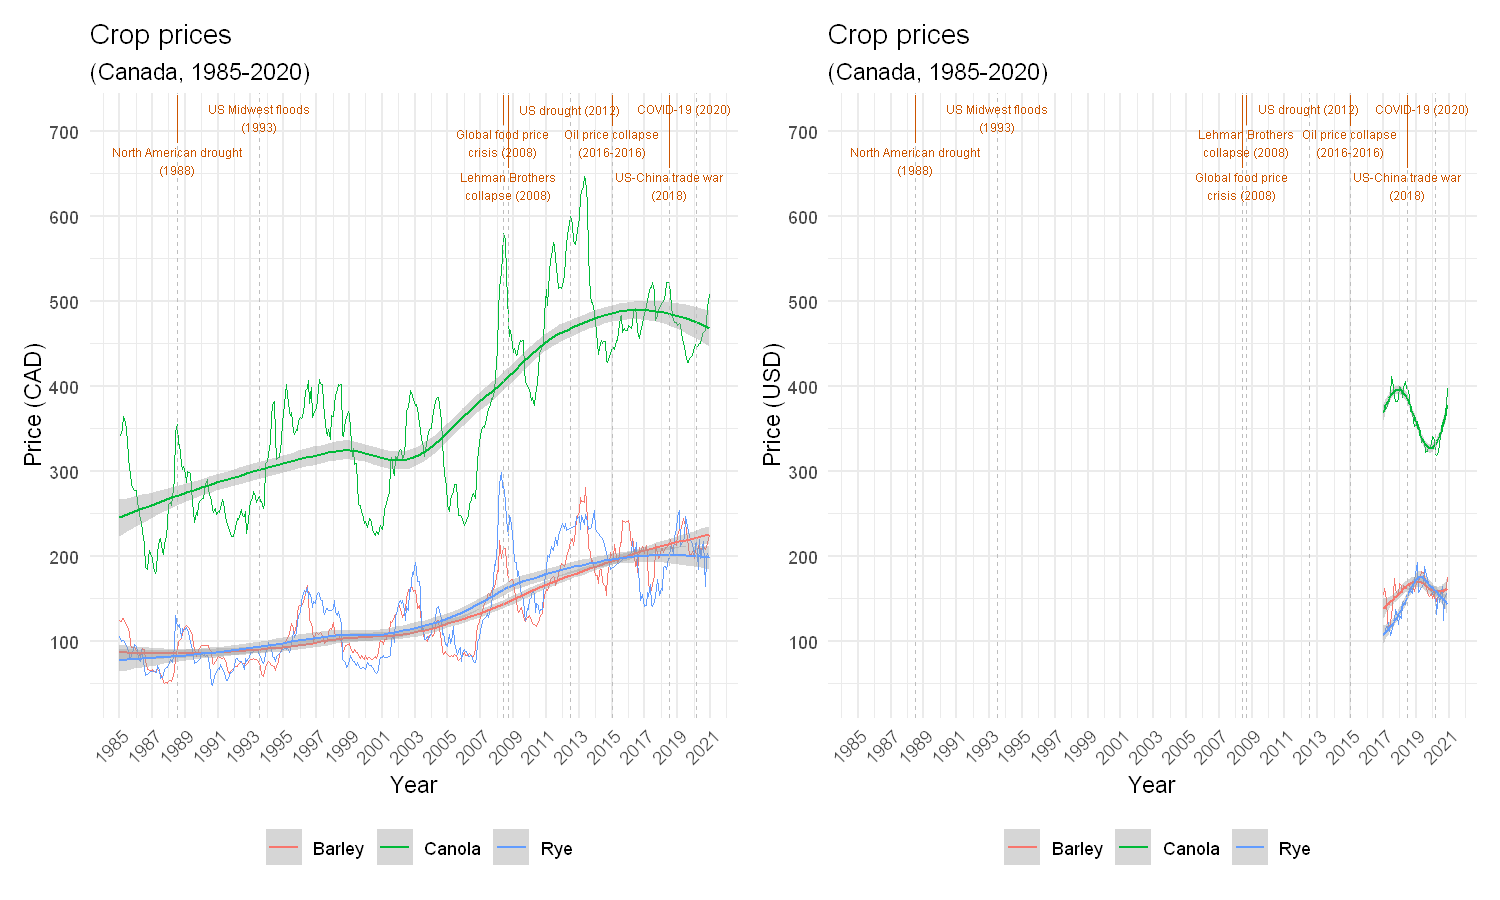

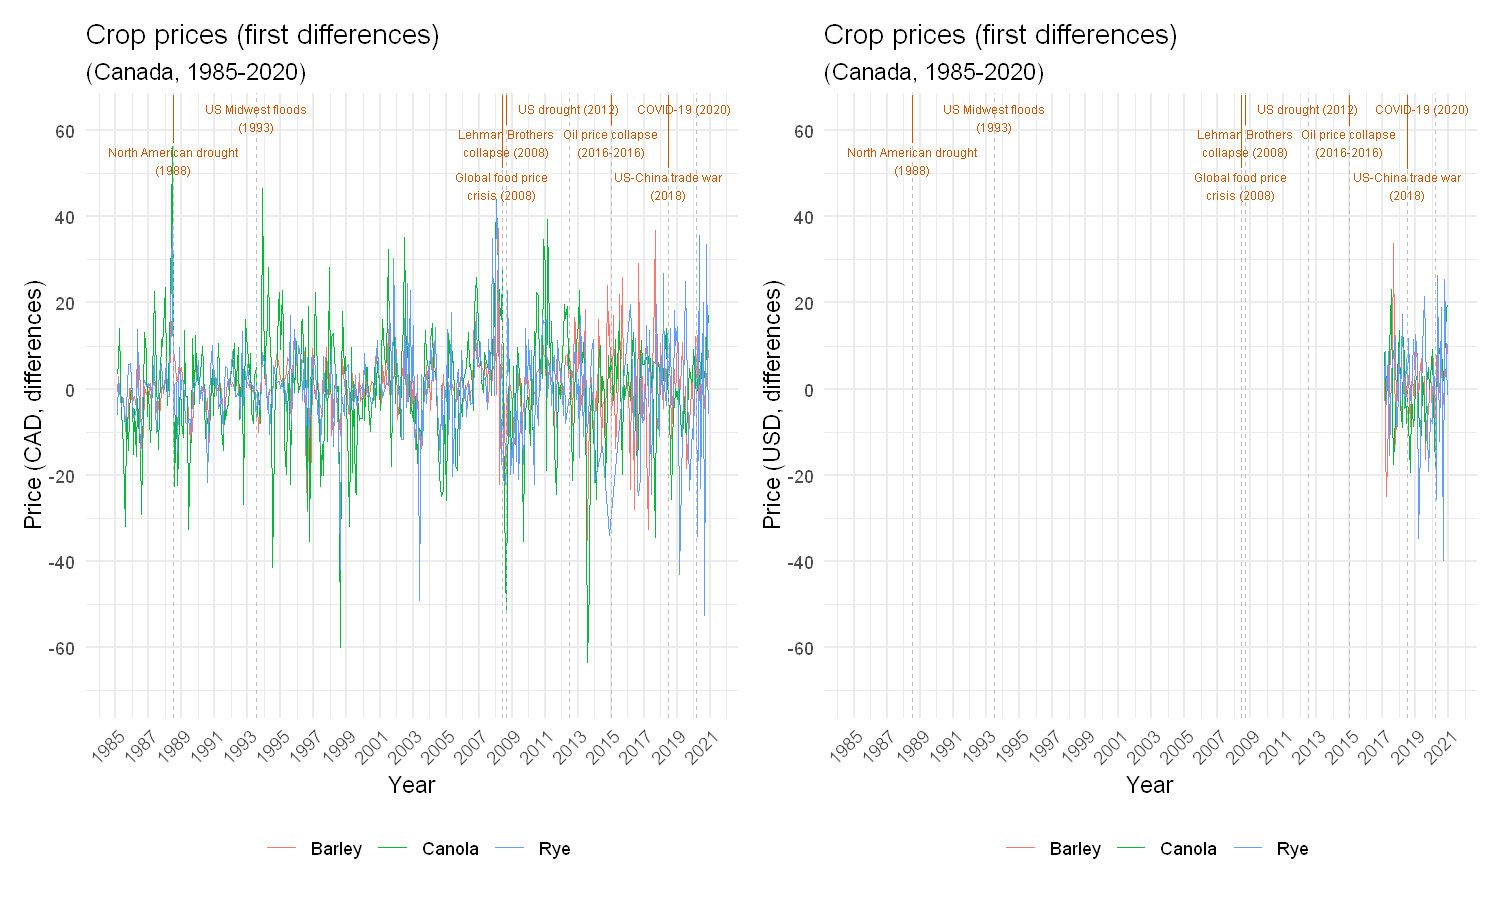

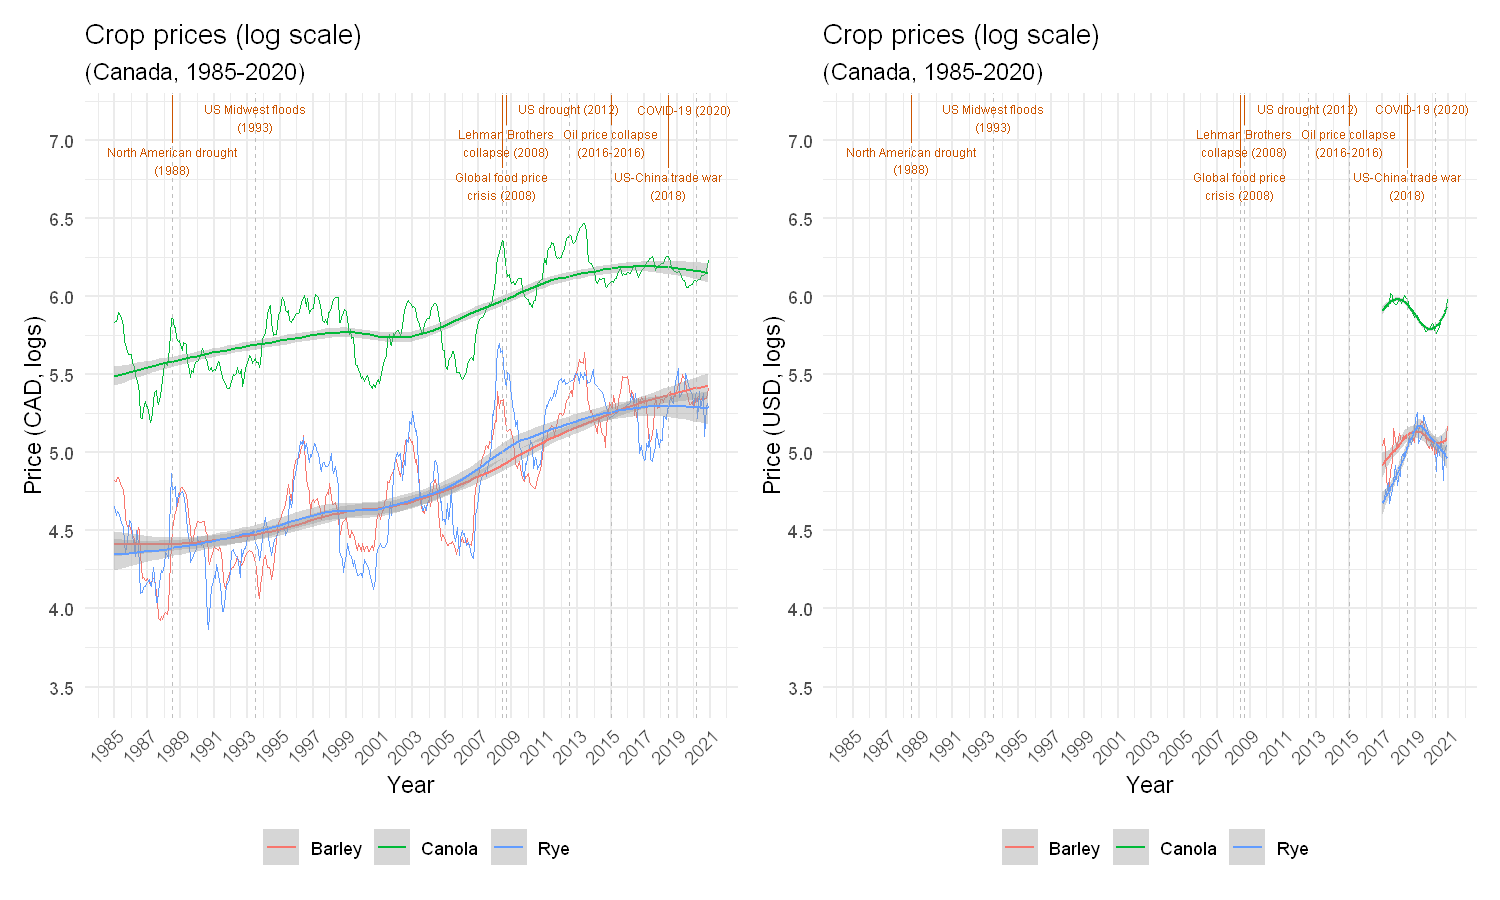

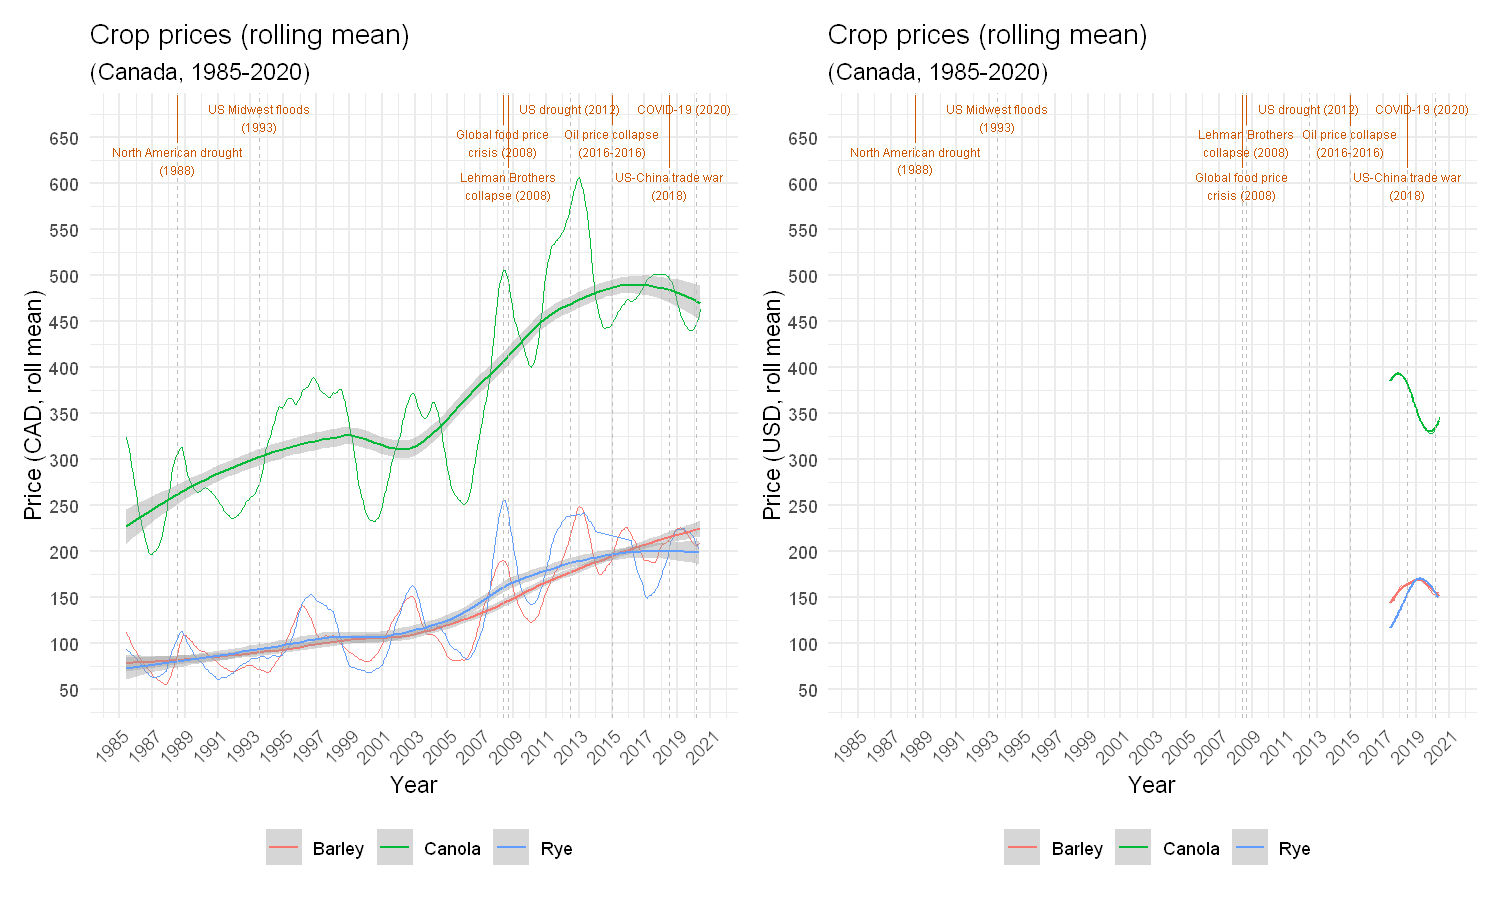

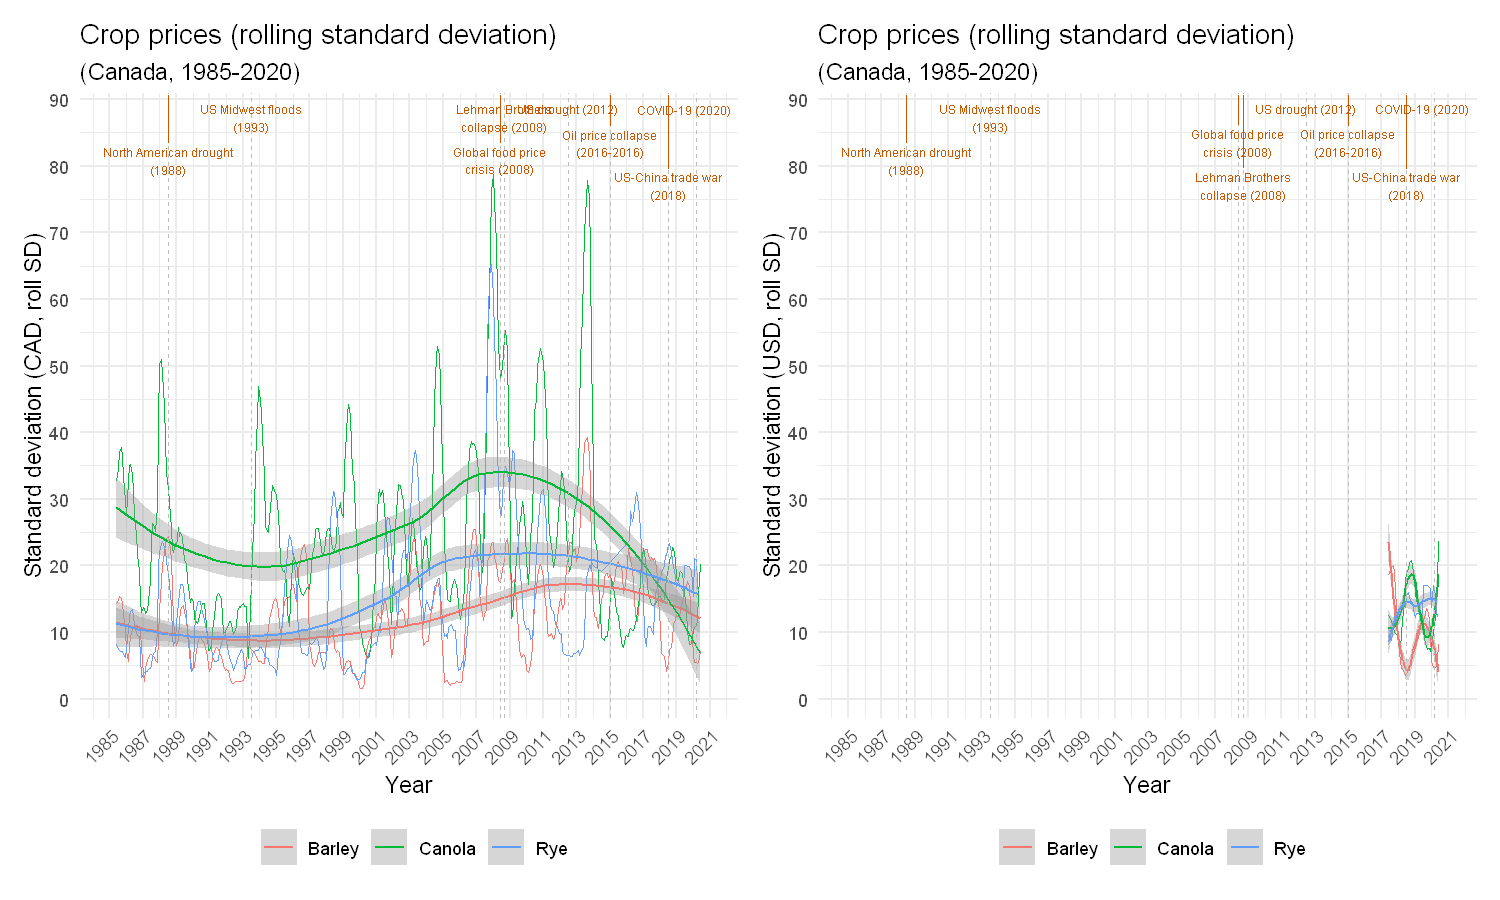

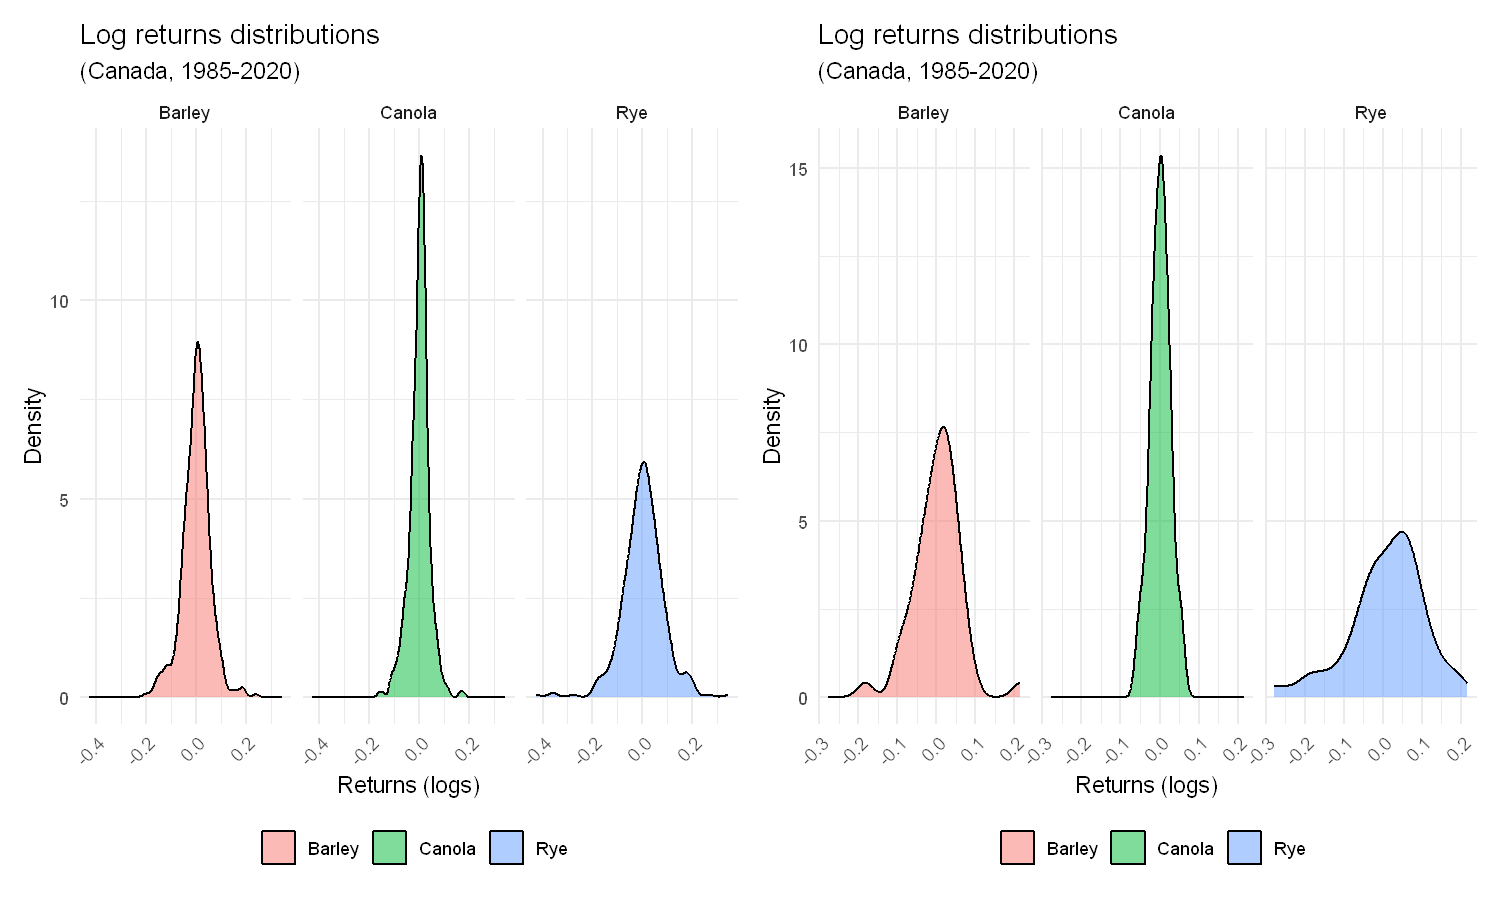

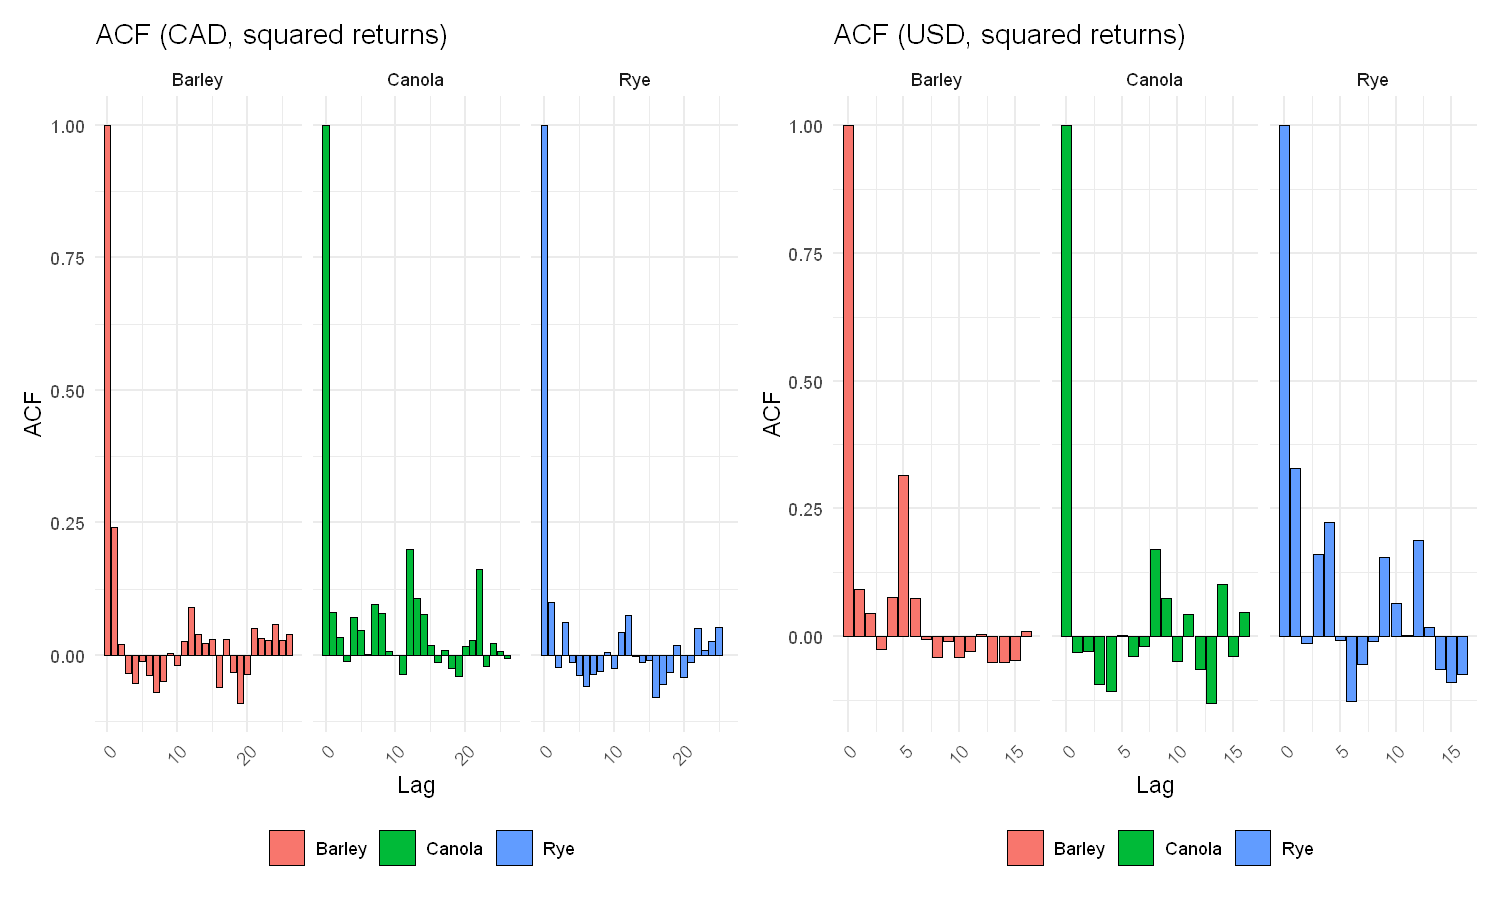

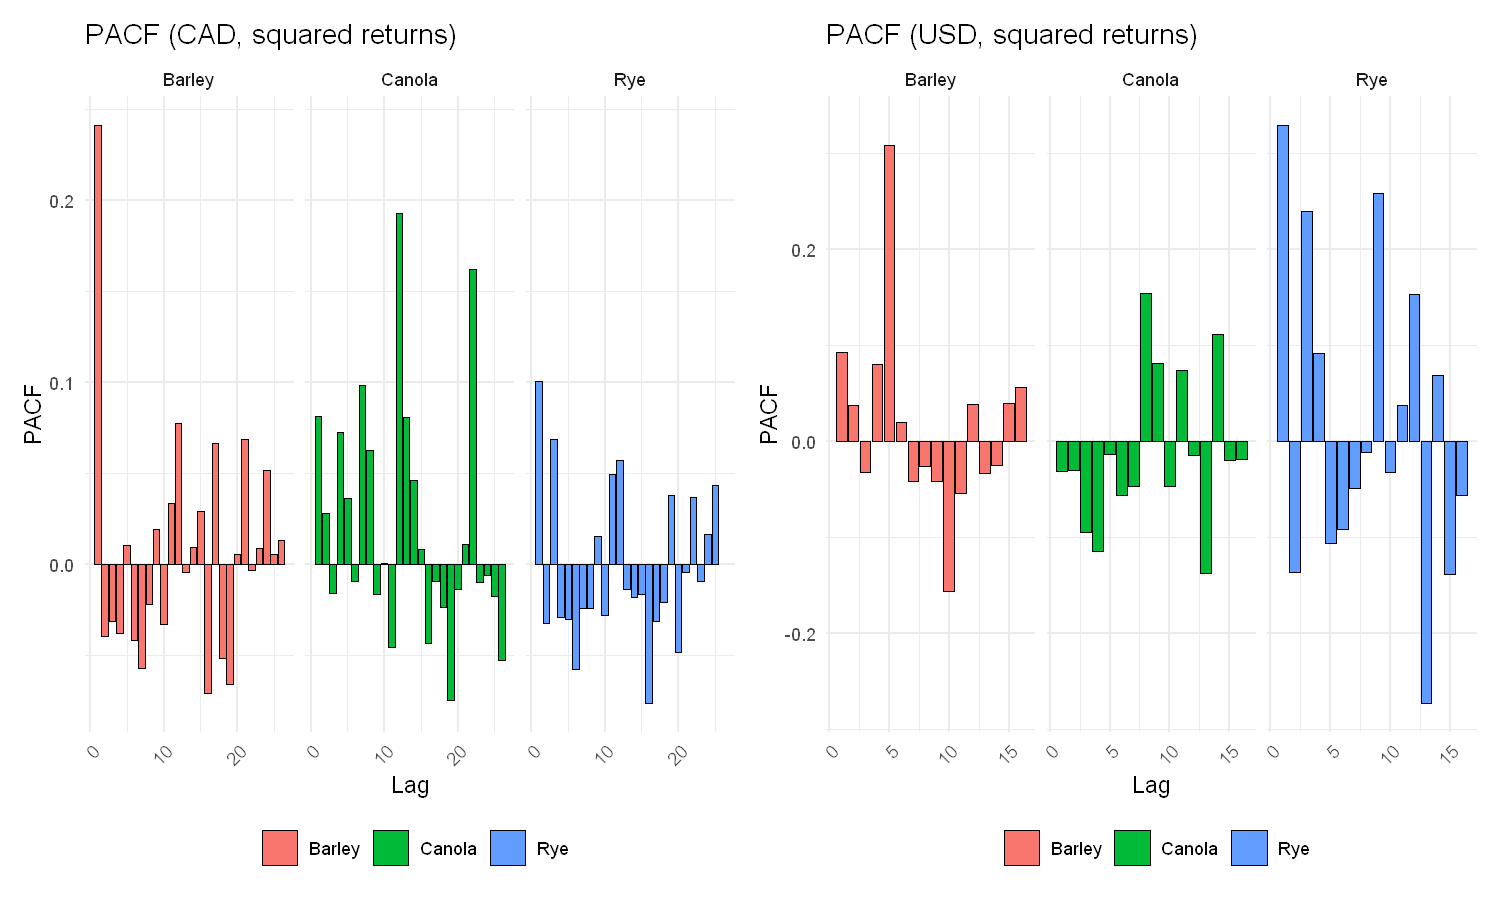

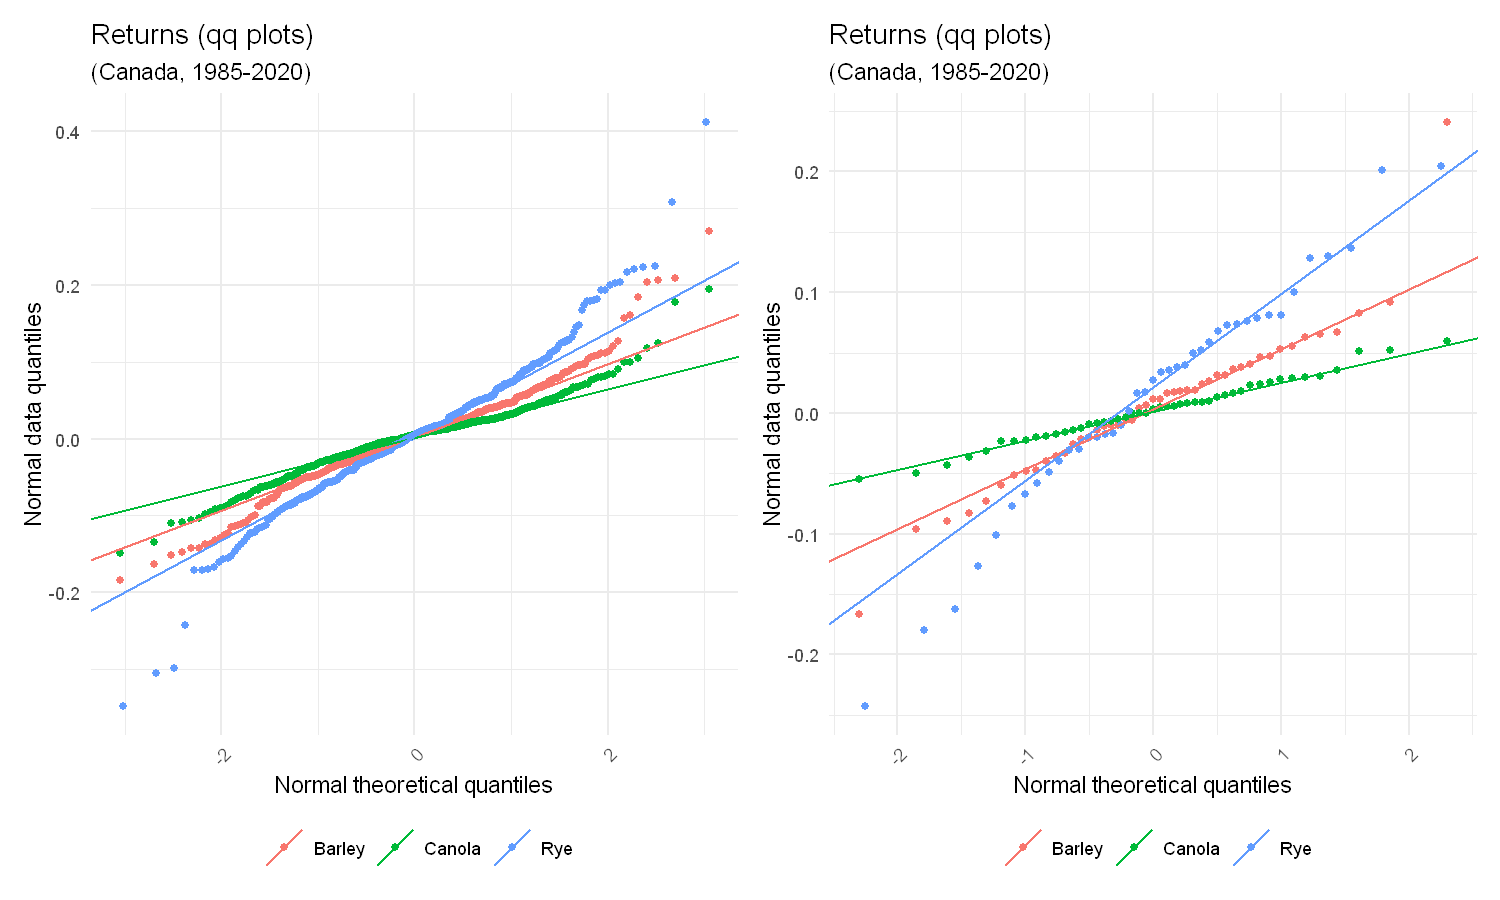

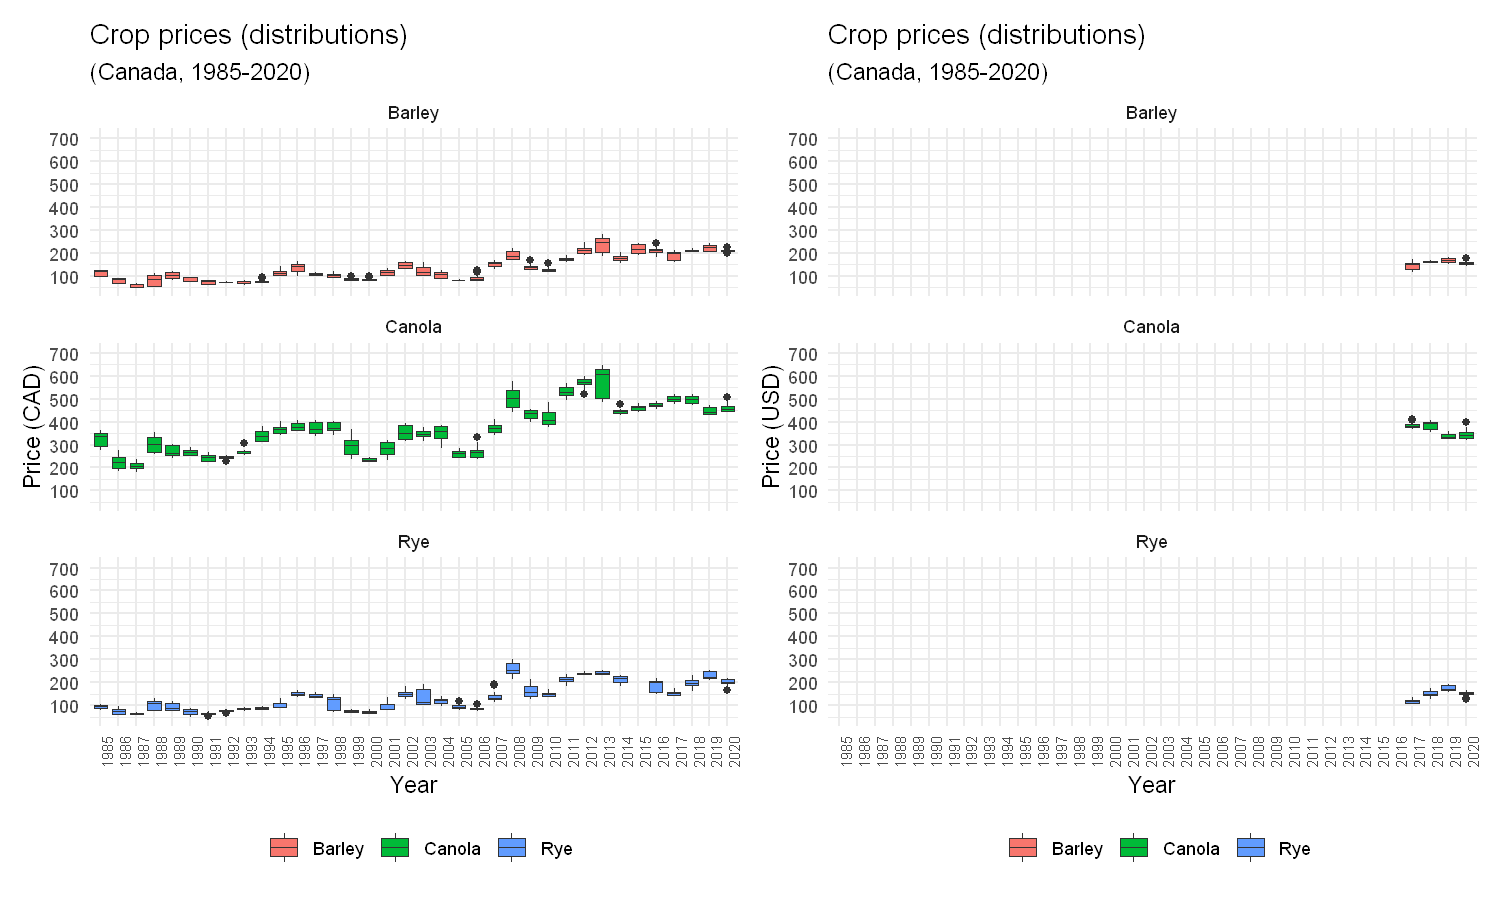

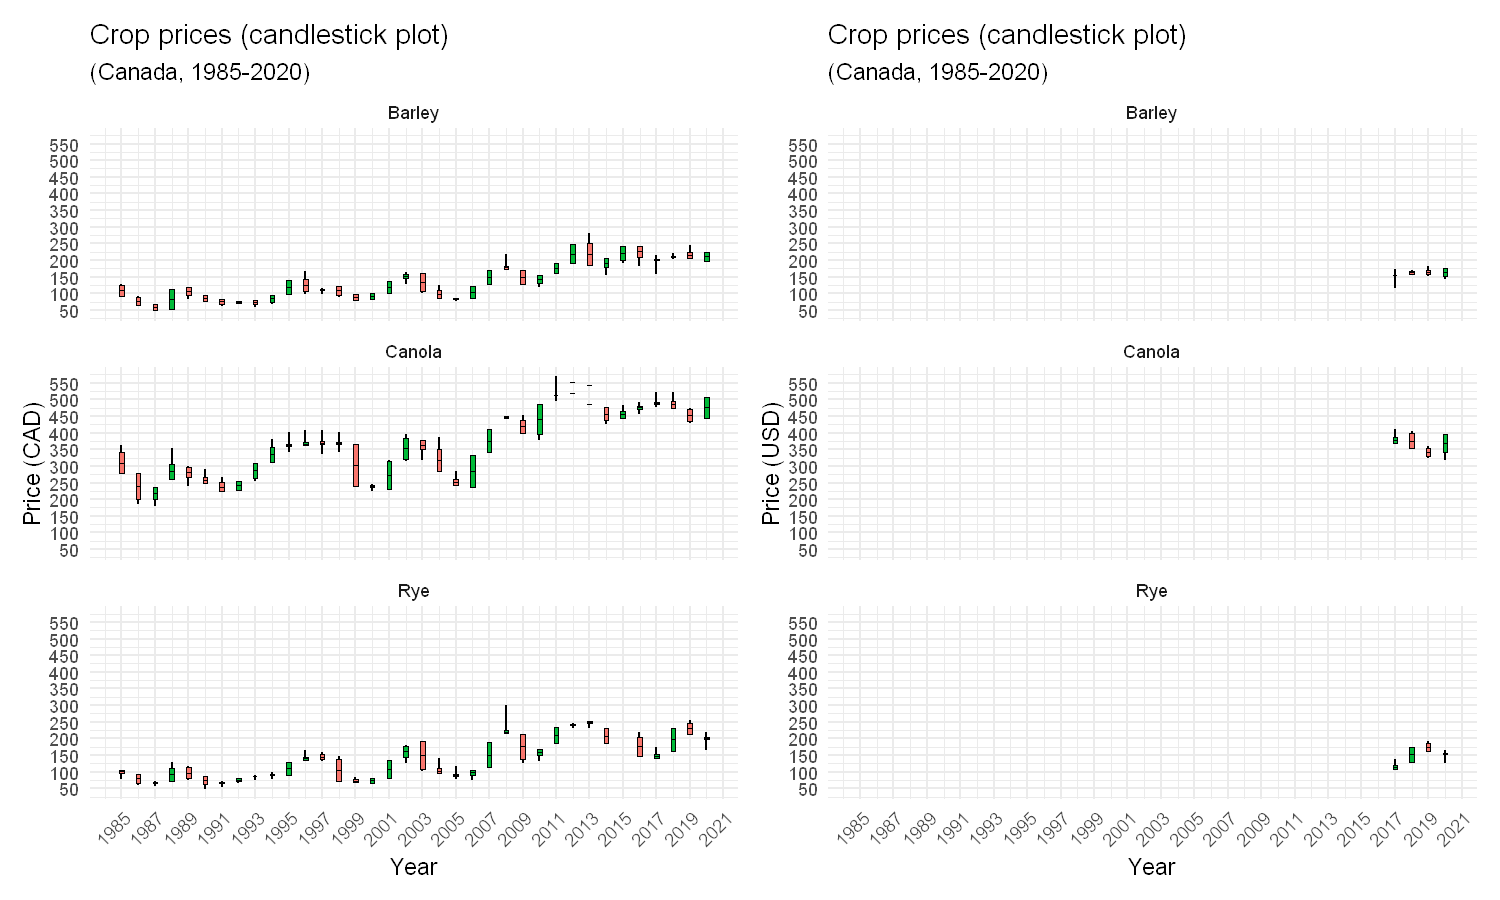

In [378]:
# Plots
for (s in series) {
    p <- paste0(currencies, "_", s)
    suppressWarnings(
        print(
            patchwork::wrap_plots(
                A = price_plots[[p[1]]], 
                B = price_plots[[p[2]]], 
                design = "AABB"
            )
        )
    )
}

...

In [379]:
# Look at the naive price-pc abandoned relationship


In [380]:
# Look at the crop prices in USD and CAD


In [381]:
# Disconnect
#dbDisconnect(c)